# Dice: exact distributions and goodness of fit

The sum of $n$ dice has an exact distribution: the $n$-fold convolution of
the single-die PMF. We compare simulations against it with Pearson's $\chi^2$
test, check the test's calibration, and measure its power to detect a
loaded die.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pcc_vizforge.plots.style import apply_matplotlib_style

apply_matplotlib_style()
SEED = 20240101

In [2]:
from pcc_vizforge.generators import DiceGenerator
from pcc_vizforge.analysis.probability import sum_pmf, sum_counts_fair

print("Ways to roll each sum with 3d6:", sum_counts_fair(3, 6))
print("Total outcomes:", sum(sum_counts_fair(3, 6)), "= 6**3")

Ways to roll each sum with 3d6: [1, 3, 6, 10, 15, 21, 25, 27, 27, 25, 21, 15, 10, 6, 3, 1]
Total outcomes: 216 = 6**3


In [3]:
gen = DiceGenerator(n_rolls=3000, n_dice=3)
rolls = gen.generate(seed=SEED)
report = gen.calculate_probabilities(rolls)
{k: report[k] for k in ("expected_sum_mean", "observed_sum_mean", "expected_sum_variance", "observed_sum_variance")}

{'expected_sum_mean': 10.5,
 'observed_sum_mean': 10.545666666666667,
 'expected_sum_variance': 8.75,
 'observed_sum_variance': 9.261001556074248}

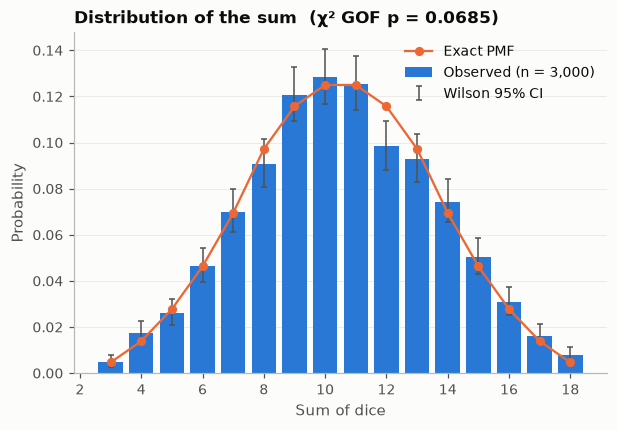

In [4]:
from pcc_vizforge.plots import diagnostics as D

support, pmf = sum_pmf(3, 6)
counts = gen.roll_sums(rolls).value_counts().reindex(support, fill_value=0)
D.dice_sum_figure(support, pmf, counts, p_value=report["sum_gof"]["p_value"]);

## Is the test calibrated?

Under $H_0$, p-values should be uniform. We simulate 300 independent experiments on spawned RNG streams.

rejection rate at 5%: 0.040


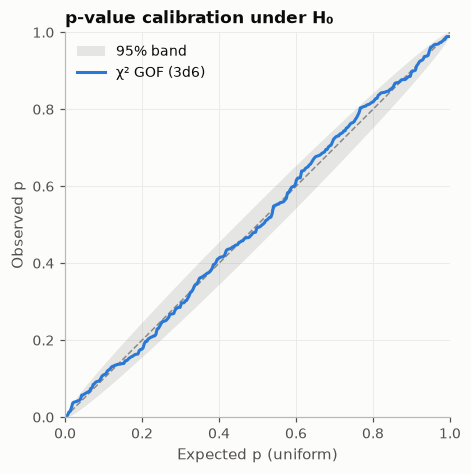

In [5]:
from pcc_vizforge.rng import spawn_seeds

pvals = [gen.calculate_probabilities(gen.generate(seed=s))["sum_gof"]["p_value"] for s in spawn_seeds(SEED, 300)]
print(f"rejection rate at 5%: {np.mean(np.array(pvals) < 0.05):.3f}")
D.pvalue_calibration_figure(pvals, label="χ² GOF (3d6)");

## Power against a loaded die

One face twice as likely as the others; the fraction of experiments that detect the loading, as a function of the number of rolls.

In [6]:
power = []
for n in (60, 120, 300, 600, 1200):
    loaded = DiceGenerator(n_rolls=n, n_dice=1, weights=[1, 1, 1, 1, 1, 2])
    rej = [loaded.fairness_test(loaded.generate(seed=s))["p_value"] < 0.05 for s in spawn_seeds(SEED, 200)]
    power.append({"rolls": n, "power": np.mean(rej)})
pd.DataFrame(power)

,rolls,power
0,60,0.400
1,120,0.695
2,300,0.995
3,600,1.000
4,1200,1.000


In [7]:
streaks = gen.generate_streak_analysis(rolls)
streaks["runs_test"]

{'name': 'wald_wolfowitz_runs',
 'statistic': 0.29581641836895717,
 'p_value': 0.7673702838163139,
 'dof': None,
 'details': {'runs': 1291,
  'expected_runs': 1283.5820267686424,
  'n_above': 1488,
  'n_below': 1127,
  'cutoff': 10.0}}